# Теория

Параллелизм - способность системы одновременно обрабатывать несколько задач

Конкурентность - несколько более широкий термин, чем параллелизм. Конкурентность предполагает, что несколько задач могут выполняться перекрывающим одна-другую образом. Конкурентность - это композиция независимых задач.

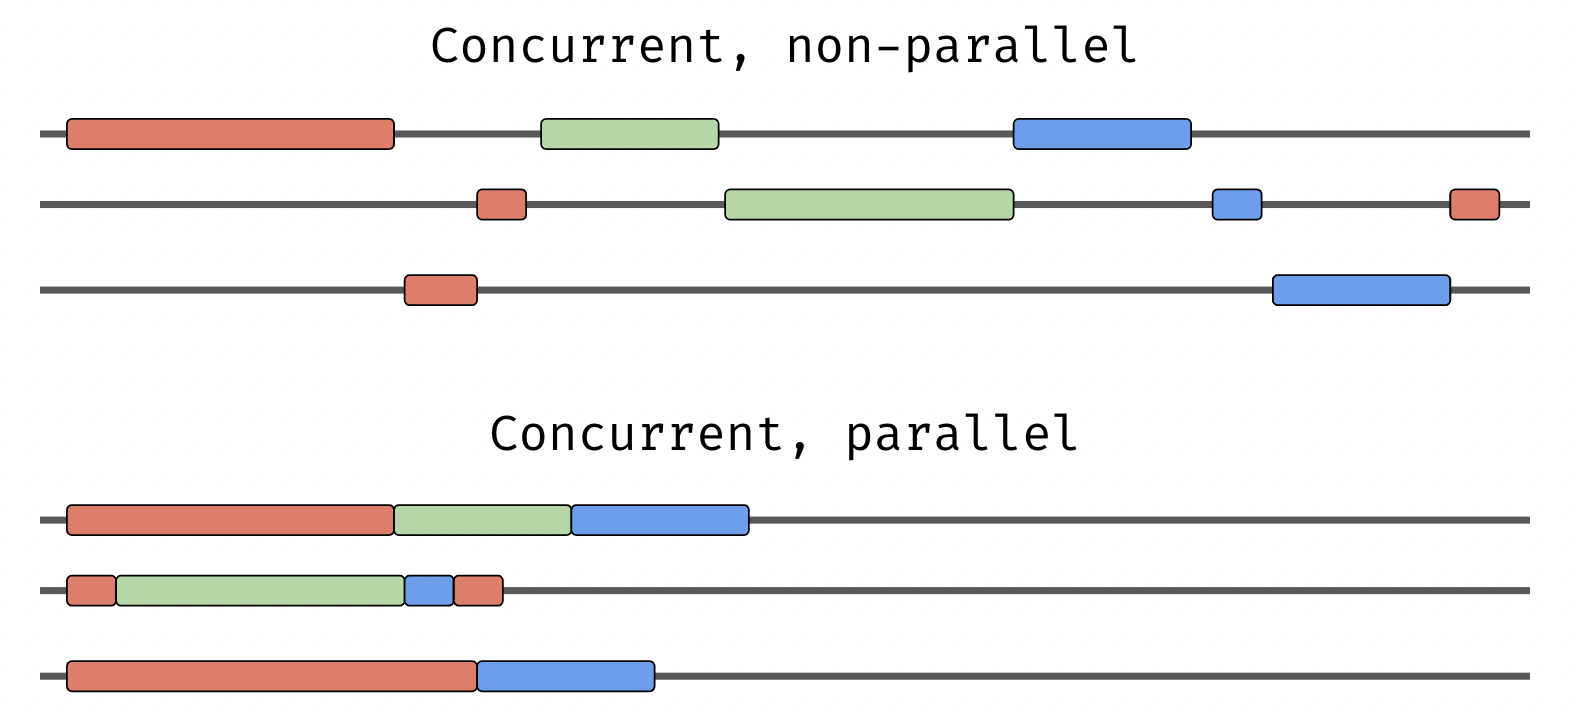

Конкурентность решает проблему ожидания (чего-либо, например ответа): мы можем не просто стоять на месте, а выполнять другие полезные задачи, пока ждём

Параллелизм решает вопрос повышения скорости обработки задач путём их распараллеливания на несколько работников

Конкурентность подходит для задач, которые зависят от внешних ресурсов (внешних сервисов, баз данных, сети), параллелизм - для задач интенсивно использующих процессор

Многозадачность - возможность выполнять несколько задач одновременно (параллельно или псевдопараллельно), переключаясь (выделяя ресурсы) с одной задачи на другую. Многозадачность бывает вытесняющей и кооперативной. Вытесняющая многозадачность - управление переключением осуществляет оперционная система (управление осуществляется сверху). Кооперативная - следующая задача выполняется только после того, как текущая задача явно объявит себя готовой отдать ресурсы другим задачам (управление снизу)

- Процесс (process) — это идентифицируемая абстракция совокупности взаимосвязанных системных ресурсов на основе отдельного и независимого виртуального адресного пространства в контексте которой организуется выполнение потоков. Каждый процесс имеет как минимум один поток. Также каждый процесс имеет свое собственное виртуальное адресное пространство и контекст выполнения, а потоки одного процесса разделяют адресное пространство процесса.
- Поток (thread) — это, сущность операционной системы, процесс выполнения на процессоре набора инструкций (программного кода). Общее назначение потоков — параллельное выполнение на процессоре двух или более различных задач. Планировщик ОС, руководствуясь приоритетом потока, распределяет кванты времени между разными потоками и ставит потоки на выполнение. Все потоки одного процесса разделяют одно адресное пространство.

Процесс старше потока

Для корректной работы очень простого счётчика ссылок в Python (считай, внутренностей интерпретатора) применяется GIL (Global Interpreter Lock или Глобальная Блокировка Интерпретатора) - это своеобразный мьютекс, работающий на уровне процесса Python, который ставится в основной цикл интерпретатора. В один момент времени только один поток может выполнять байт-код. Переключение потоков (с действующего на другие) может происходить по таймеру / если действующий поток стал ожидать (sleep) / если действующий поток пытается осуществить ввод-вывод / по исчерпании лимита инструкций у действующего потока.

### threading & GIL

Модуль threading позволяет управлять (создавать / закрывать) потоками OС. GIL в Python не позволяет потокам работать одновременно, тем не менее потоки могут выполяться конкурентно (переключаясь на ожиданиях). threading позволяет реализовать не параллельную (конкурентную) вытесняющую (так как создаются обычные потоки ОС, управляемые самой ОС) многозадачность.

Потоки подойдут для тех ситуаций, когда задачи много времени ожидают (sleep, ввода-вывода, в общем IO-Bound) и логически распараллеливаются, например - несколько сетевых запросов. Потоки в Python не подойдут для задач, в которых активно участвует CPU (CPU-Bound).

Также стоит помнить, о том что максимальное число потоков в ОС ограничено, как нарочно, скажем, числом дескрипторов (65к), так и естественно, например размером стека (8176 Б). Кроме того, переключение между потоками - это не простая операция, и чем больше потоков в 1 процессе, тем более она дорогостоящая.

Так как потоки работают в одном адресном пространстве, каждый поток может обратиться ко всему множеству объектов программы.

Как и в любой другой многопоточной программе, в python возможна ситуация гонки потоков. Для того чтобы спраиться с этим явлением, предусмторенны средства синхронизации.
- threading.Lock - обычный мьютекс
- threading.RLock - повторно используемый мьютекс
- threading.Event - событие
- threading.Condition - условие
- threading.Semaphore - семафор

### multiproccessing

Модуль multiprocessing позволяет управлять (создавать / закрывать) процессами OС. GIL не имеет власти над процессами. Процессы позволяют реализовать настоящую параллельную (конкурентную) вытесняющую (так как создаются обычные процессы ОС - считай, новые интерпретаторы, и если число действующих процессов превысит число ядер CPU, они начнут конкурировать за процессорное время) многозадачность.

Переключение между процессами - сложная и очень дорогостоящая операция. Эффективное число процессов в программе <= общего числа ненагруженных ядер CPU.

Процессы подойдут для тех ситуаций, когда задачи требуют большой вычислительной работы (CPU-Bound) и логически распараллеливаются, например - преобразование множества изображений / расчёт множества криптографических хешей.

Так как каждый процесс функционирует в изолированном адресном пространстве, данные между процессами невозможно передавать напрямую. Средства (способы), которые служат для передачи данных между процессами:

- через файлы или любые другие внешние ресурсы (очереди, базы данных и т.п.)
- через SharedMemory https://docs.python.org/3/library/multiprocessing.shared_memory.html
- через Manager, но этот подход считается не оптимальным
- через пайпы и очереди https://docs.python.org/3/library/multiprocessing.html#pipes-and-queues

### Асинхронность

Модуль asyncio и специализированные модули для асинхронной работы с сетевыми объектами позволяют управлять (создавать, запускать, ожидать, закрывать) корутинами (сопрограммами). В основе работы асинхронности лежит Цикл событий (Event Loop), который взаимодействует с корутинами, так чтобы каждая из них выполнялась оптимальное время, при этом управляет потоком выполнения разработчик (= сама программа) при помощи специальных инструкций async / await и некоторых других.

Цикл событий работает в 1 потоке Python, а значит на него накладываются ограничения GIL. Цикл событий позволяет реализовать не параллельную (конкурентную) кооперативную многозадачность.

Корутины это очень маленькие объекты Python. Переключение между корутинами - очень быстрая операция (зависит от реализации - от O(1) до O(n)). Эффективное число корутин в программе определяется ограничениями сети и системы.

Асинхронность подойдёт для тех ситуаций, когда задачи много времени ожидают сеть и логически распараллеливаются. Асинхронность в Python не подойдёт для задач, в которых активно участвует CPU (CPU-Bound) и IO операции отличны от сетевых (например, задача чтения с диска).

Для того чтобы использовать асинхронные возможности языка, необходимо использовать асинхронные библиотеки

Кроме того, задачи необходимо ставить циклу событий на исполнение при помощи специальных функций

Если корутину нужно обработать внутри задачи, уже поставленной Циклу событий на исполнение, её можно вызвать при помощи простой инструкции await

Для эффективной работы с asyncio необходимо помнить о том что сеть это тоже ресурс, кроме того требуется знать особенности системы на которой будет выполняться код, учитывать что сессии (как и соединения) это весьма крупные объекты и их лучше переиспользовать. Всегда необходимо ограничивать количество одновременно запускаемых сопрограмм.

Модуль asyncio содержит стандартные инструменты синхронизации: Lock, Event, Condition

async превращает обычную функцию в корутину (coroutine) - особый вид функции, которая может приостанавливать свое выполнение и возобновлять его позже

Ключевые возможности async:
- Использовать await внутри - только асинхронные функции могут содержать await
- Может приостанавливаться - отдавать управление event loop'у
- Выполняется не сразу - при вызове возвращает объект корутины, который нужно запустить через await или asyncio.run()

Синхронная функция - Функция, которая выполняется от начала до конца без возможности прерывания извне. Она блокирует поток выполнения, пока не завершится. Проблема синхронных функций: Пока они работают, программа не может делать ничего другого - ни обрабатывать другие запросы, ни реагировать на события.

Что значит "заблокировать основной асинхронный цикл"? Event loop (асинхронный цикл) - это диспетчер, который управляет выполнением асинхронных задач. - Он постоянно работает в цикле:
- Берет задачу (корутину)
- Выполняет ее до первого await
- Переключается на другую задачу
- И так по кругу

Блокировка event loop - когда какая-то операция не возвращает управление event loop'у, и он не может переключиться на другие задачи

await означает: "Приостановить текущую корутину здесь и отдать управление event loop'у, а когда результат будет готов - возобновить выполнение". 
Что именно дает await:
- Не блокирует поток - пока ожидаем результат, Python может выполнять другие задачи
- Позволяет конкурентность - сотни задач могут ждать разных событий одновременно
- Отслеживает готовность - когда результат готов (например, пришли данные из сети), event loop автоматически возобновит корутину

Пробуждение спящей корутины устроено так. Event loop получает уведомление от операционной системы (или от другого механизма) и возобновляет корутину с готовым результатом. Корутина не проверяет периодически "а результат уже готов?". Она полностью засыпает, и event loop будит её только тогда, когда результат реально появился. Это называется асинхронное ожидание на основе событий (event-driven async waiting).

Блокирующая операция - любая операция, которая заставляет программу ждать (простаивать) без возможности делать что-то полезное

drain() решает проблему управления потоком данных (flow control). drain() - проверяет:
- Есть ли место в буфере?
- Если нет - приостанавливает корутину
- Когда ОС отправила часть данных и буфер освободился - возобновляет

Backpressure - естественным образом замедляет отправителя до скорости получателя. Зачем это нужно:
- Предотвращает потерю данных - буфер не переполняется
- Эффективное использование сети - не отправляем быстрее, чем уходит
- Автоматическая подстройка скорости - отправитель синхронизируется с получателем

Что такое семафор? Коротко: Семафор - это "пропускной пункт", который ограничивает количество корутин, одновременно выполняющих определенный блок кода.

Что такое оркестрация? Коротко: Оркестрация - это управление и координация множества асинхронных задач: их запуск, ожидание, обработка результатов, ограничение параллелизма. Все по аналогии с оркестром.